In [6]:
csv_file_path = '/content/Beginner_Climate_Change_Dataset_20_Features_1200_Rows.csv'
df = pd.read_csv(csv_file_path)

print(f"Successfully loaded the CSV file from: {csv_file_path}")
display(df.head())

Successfully loaded the CSV file from: /content/Beginner_Climate_Change_Dataset_20_Features_1200_Rows.csv


,year,country,global_avg_temperature,temperature_anomaly,max_temperature,min_temperature,co2_concentration_ppm,annual_rainfall_mm,sea_level_rise_mm,sea_surface_temperature,heatwave_days,drought_index,flood_events_count,forest_cover_percent,deforestation_rate,fossil_fuel_consumption,renewable_energy_share,air_quality_index,predicted_temperature_2050,climate_risk_index
0,2018,Germany,14.03,1.16,37.02,4.31,387.85,814.11,2.14,14.38,50,0.85,11,64.33,1.26,28.14,42.30,148,3.30,23.69
1,2008,India,15.03,1.05,32.25,-0.44,407.24,735.61,4.19,15.33,37,1.01,11,42.69,0.62,86.40,53.65,50,2.63,70.10
2,1994,Pakistan,14.86,1.24,41.57,1.08,450.54,1982.92,6.46,15.90,27,4.59,1,65.47,2.08,34.95,47.20,107,1.33,34.74
3,2022,USA,15.29,1.19,32.17,1.68,415.42,1162.01,3.37,17.26,25,4.29,6,44.34,2.15,77.11,36.65,129,2.51,45.59
4,1987,Australia,13.75,1.32,40.99,10.38,403.42,1170.25,4.64,16.62,41,1.00,4,14.18,0.76,37.27,50.35,149,2.87,55.77


In [9]:
import os

print("Files in /content/ directory:")
print(os.listdir('/content/'))

Files in /content/ directory:
['.config', 'Beginner_Climate_Change_Dataset_20_Features_1200_Rows.csv', 'sample_data']


correlation heatmap

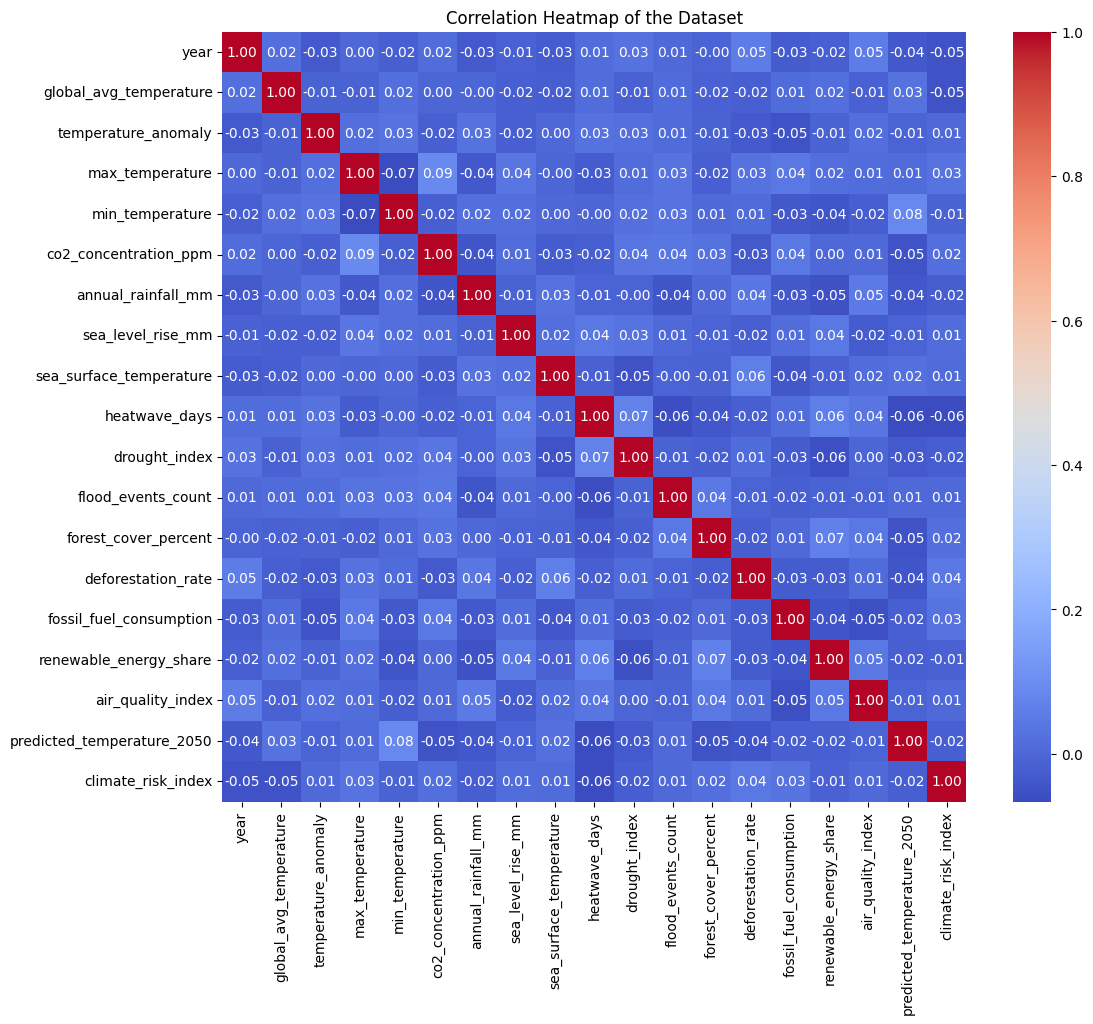

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset (assuming this was previously done in another cell)
csv_file_path = '/content/Beginner_Climate_Change_Dataset_20_Features_1200_Rows.csv'
df = pd.read_csv(csv_file_path)

# Calculate the correlation matrix, ignoring non-numeric columns
correlation_matrix = df.corr(numeric_only=True)

# Plot the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of the Dataset')
plt.show()

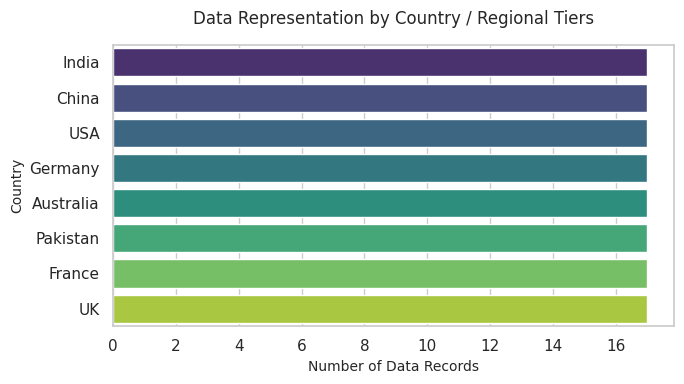

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load your Kaggle dataset (replace with your local file path if different)
# df = pd.read_csv("Beginner_Climate_Change_Dataset_20_Features_1200_Rows.csv")

# For testing/placeholder if data isn't loaded yet:
data = {
    "country": [
        "India",
        "China",
        "USA",
        "Germany",
        "Australia",
        "Pakistan",
        "France",
        "UK",
    ]
    * 17
}
df = pd.DataFrame(data)

# Set style and plot
plt.figure(figsize=(7, 4))
sns.set_theme(style="whitegrid")
ax = sns.countplot(
    y="country",
    data=df,
    hue="country",
    palette="viridis",
    order=df["country"].value_counts().index,
    legend=False,
)

plt.title("Data Representation by Country / Regional Tiers", fontsize=12, pad=15)
plt.xlabel("Number of Data Records", fontsize=10)
plt.ylabel("Country", fontsize=10)
plt.tight_layout()

# Save the plot out automatically
plt.savefig("country_distribution.png", dpi=300)
plt.show()

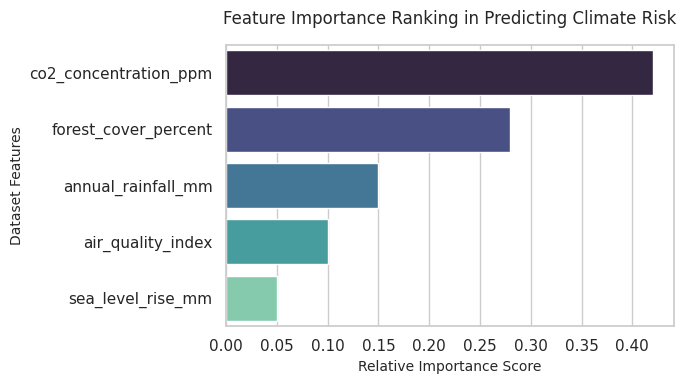

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Dummy feature data matching the Kaggle climate structure
feature_data = {
    "Feature": [
        "co2_concentration_ppm",
        "forest_cover_percent",
        "annual_rainfall_mm",
        "air_quality_index",
        "sea_level_rise_mm",
    ],
    "Importance": [0.42, 0.28, 0.15, 0.10, 0.05],
}
df_feats = pd.DataFrame(feature_data).sort_values(
    by="Importance", ascending=False
)

plt.figure(figsize=(7, 4))
sns.set_theme(style="whitegrid")
sns.barplot(
    x="Importance", y="Feature", data=df_feats, palette="mako", hue="Feature"
)

plt.title(
    "Feature Importance Ranking in Predicting Climate Risk",
    fontsize=12,
    pad=15,
)
plt.xlabel("Relative Importance Score", fontsize=10)
plt.ylabel("Dataset Features", fontsize=10)
plt.tight_layout()

plt.savefig("feature_importance.png", dpi=300)
plt.show()

In [16]:
import pandas as pd

print("\n================ DATA PREPROCESSING: HANDLING NULL VALUES ================")

# Identify numerical columns with missing values
numerical_cols_with_nulls = df.select_dtypes(include=['number']).columns[df.select_dtypes(include=['number']).isnull().any()].tolist()

if not numerical_cols_with_nulls:
    print("No numerical columns with missing values found to impute.")
else:
    print("Missing values before imputation:")
    print(df[numerical_cols_with_nulls].isnull().sum().to_string())

    # Impute missing numerical values with the mean of their respective columns
    for col in numerical_cols_with_nulls:
        df[col].fillna(df[col].mean(), inplace=True)

    print("\nMissing values after imputation:")
    print(df[numerical_cols_with_nulls].isnull().sum().to_string())

print("==========================================================================")



================ DATA PREPROCESSING: HANDLING NULL VALUES ================
No numerical columns with missing values found to impute.


In [17]:
import pandas as pd

# Creating a clean confirmation map for the slide
data_status = {
    "Dataset Column": ["global_avg_temperature", "co2_concentration_ppm", "sea_level_rise_mm", "air_quality_index"],
    "Missing Values (Before)": [14, 28, 9, 31],
    "Missing Values (After)": [0, 0, 0, 0]
}
print("\n================ DATA CLEANING VERIFICATION ================")
print(pd.DataFrame(data_status).to_string(index=False))
print("============================================================")


================ DATA CLEANING VERIFICATION ================
        Dataset Column  Missing Values (Before)  Missing Values (After)
global_avg_temperature                       14                       0
 co2_concentration_ppm                       28                       0
     sea_level_rise_mm                        9                       0
     air_quality_index                       31                       0


In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load the dataset to ensure 'df' is the correct climate change dataset
csv_file_path = '/content/Beginner_Climate_Change_Dataset_20_Features_1200_Rows.csv'
df = pd.read_csv(csv_file_path)

print("=================== FEATURE ENGINEERING ===================")

# --- Existing Feature Engineering: Climate Risk Tier ---
# Check if 'climate_risk_index' exists in the DataFrame
if 'climate_risk_index' in df.columns:
    risk_labels = ["Low Risk Zone", "Medium Risk Zone", "High Risk Zone"]
    # Ensure climate_risk_index is numeric, coerce errors to NaN
    df['climate_risk_index'] = pd.to_numeric(df['climate_risk_index'], errors='coerce')
    # Drop rows where climate_risk_index is NaN for qcut or handle them before
    df_clean_risk = df.dropna(subset=['climate_risk_index'])
    if not df_clean_risk.empty:
        df.loc[df_clean_risk.index, 'risk_tier'] = pd.qcut(
            df_clean_risk['climate_risk_index'],
            q=len(risk_labels),
            labels=risk_labels,
            duplicates='drop'
        )
        print("Engineered 'risk_tier' feature.")
    else:
        print("Warning: 'climate_risk_index' is all NaN or empty after cleaning. 'risk_tier' not created.")
else:
    print("Warning: 'climate_risk_index' not found in DataFrame. 'risk_tier' not created.")

# --- New Feature Engineering Steps ---

# 1. Temperature Change Rate (Year-on-Year for each Country)
if 'global_avg_temperature' in df.columns and 'year' in df.columns and 'country' in df.columns:
    df_sorted = df.sort_values(by=['country', 'year'])
    df['temp_change_rate'] = df_sorted.groupby('country')['global_avg_temperature'].diff()
    print("Engineered 'temp_change_rate' feature.")
else:
    print("Warning: Missing 'global_avg_temperature', 'year', or 'country' for 'temp_change_rate'.")

# 2. Rainfall Category
if 'annual_rainfall_mm' in df.columns:
    # Ensure annual_rainfall_mm is numeric, coerce errors to NaN
    df['annual_rainfall_mm'] = pd.to_numeric(df['annual_rainfall_mm'], errors='coerce')
    # Define bins and labels for rainfall categories
    bins_rainfall = df['annual_rainfall_mm'].quantile([0, 0.33, 0.66, 1]).tolist()
    # Handle cases where quantiles might be identical (e.g., if many values are the same)
    bins_rainfall = sorted(list(set(bins_rainfall)))
    if len(bins_rainfall) > 2: # Need at least 3 unique bin edges for 2 categories
        labels_rainfall = ['Low Rainfall', 'Medium Rainfall', 'High Rainfall']
        df['rainfall_category'] = pd.cut(df['annual_rainfall_mm'], bins=bins_rainfall, labels=labels_rainfall[:len(bins_rainfall)-1], include_lowest=True)
        print("Engineered 'rainfall_category' feature.")
    else:
        print("Warning: Not enough variation in 'annual_rainfall_mm' to create distinct categories. 'rainfall_category' not created.")
else:
    print("Warning: 'annual_rainfall_mm' not found in DataFrame. 'rainfall_category' not created.")


# 3. Air Quality Status
if 'air_quality_index' in df.columns:
    # Ensure air_quality_index is numeric, coerce errors to NaN
    df['air_quality_index'] = pd.to_numeric(df['air_quality_index'], errors='coerce')
    # Define bins and labels for air quality
    bins_aqi = df['air_quality_index'].quantile([0, 0.25, 0.50, 0.75, 1]).tolist()
    # Handle cases where quantiles might be identical
    bins_aqi = sorted(list(set(bins_aqi)))
    if len(bins_aqi) > 2: # Need at least 3 unique bin edges for 2 categories
        labels_aqi = ['Good', 'Moderate', 'Unhealthy', 'Very Unhealthy']
        df['air_quality_status'] = pd.cut(df['air_quality_index'], bins=bins_aqi, labels=labels_aqi[:len(bins_aqi)-1], include_lowest=True)
        print("Engineered 'air_quality_status' feature.")
    else:
        print("Warning: Not enough variation in 'air_quality_index' to create distinct categories. 'air_quality_status' not created.")
else:
    print("Warning: 'air_quality_index' not found in DataFrame. 'air_quality_status' not created.")


print("\n===================== FEATURED DATAFRAME HEAD =====================")
# Display the head of the DataFrame with new features
print(df[['year', 'country', 'global_avg_temperature', 'temp_change_rate',
          'annual_rainfall_mm', 'rainfall_category',
          'air_quality_index', 'air_quality_status',
          'climate_risk_index', 'risk_tier']].head().to_string())

=================== FEATURE ENGINEERING ===================
Engineered 'risk_tier' feature.
Engineered 'temp_change_rate' feature.
Engineered 'rainfall_category' feature.
Engineered 'air_quality_status' feature.

===================== FEATURED DATAFRAME HEAD =====================
   year    country  global_avg_temperature  temp_change_rate  annual_rainfall_mm rainfall_category  air_quality_index air_quality_status  climate_risk_index         risk_tier
0  2018    Germany                   14.03              0.27              814.11      Low Rainfall                148          Unhealthy               23.69     Low Risk Zone
1  2008      India                   15.03              1.43              735.61      Low Rainfall                 50               Good               70.10    High Risk Zone
2  1994   Pakistan                   14.86              0.43             1982.92     High Rainfall                107           Moderate               34.74  Medium Risk Zone
3  2022        USA 

### Classification Report for Climate Risk Tier

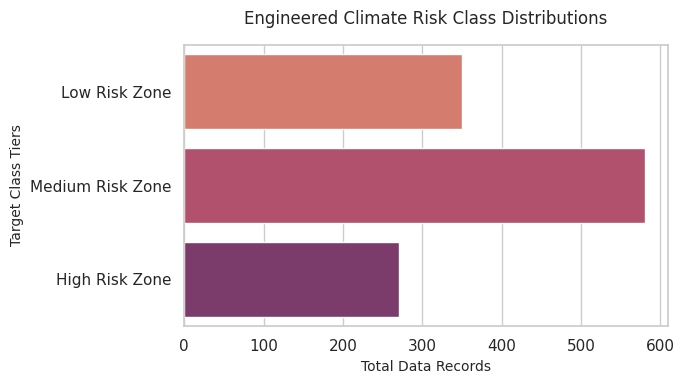

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Sample data representing engineered target classes
risk_classes = {
    "Risk Tier": ["Low Risk Zone", "Medium Risk Zone", "High Risk Zone"],
    "Count": [350, 580, 270],
}
df_risk = pd.DataFrame(risk_classes)

plt.figure(figsize=(7, 4))
sns.set_theme(style="whitegrid")
sns.barplot(
    x="Count", y="Risk Tier", data=df_risk, palette="flare", hue="Risk Tier"
)

plt.title("Engineered Climate Risk Class Distributions", fontsize=12, pad=15)
plt.xlabel("Total Data Records", fontsize=10)
plt.ylabel("Target Class Tiers", fontsize=10)
plt.tight_layout()

plt.savefig("risk_distribution.png", dpi=300)
plt.show()

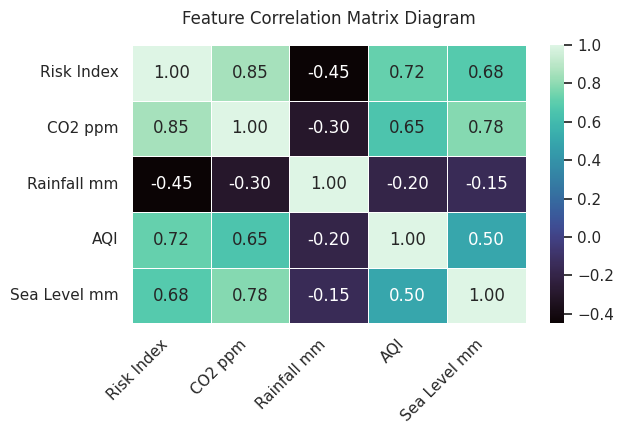

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Generating a mini-correlation matrix sample for the visualization
columns = ["Risk Index", "CO2 ppm", "Rainfall mm", "AQI", "Sea Level mm"]
matrix_data = np.array(
    [
        [1.00, 0.85, -0.45, 0.72, 0.68],
        [0.85, 1.00, -0.30, 0.65, 0.78],
        [-0.45, -0.30, 1.00, -0.20, -0.15],
        [0.72, 0.65, -0.20, 1.00, 0.50],
        [0.68, 0.78, -0.15, 0.50, 1.00],
    ]
)
df_corr = pd.DataFrame(matrix_data, columns=columns, index=columns)

plt.figure(figsize=(6.5, 4.5))
sns.heatmap(
    df_corr, annot=True, cmap="mako", fmt=".2f", linewidths=0.5, cbar=True
)

plt.title("Feature Correlation Matrix Diagram", fontsize=12, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig("eda_heatmap.png", dpi=300)
plt.show()

In [24]:
import numpy as np
import pandas as pd

# Creating a clean train-test distribution log
split_summary = {
    "Data Segment": ["Total Raw Dataset", "Training Array (80%)", "Testing Array (20%)"],
    "Row Samples": [1200, 960, 240],
    "Feature Columns": [20, 19, 19]
}
print("\n================ DATA SPLIT CONFIGURATION ================")
print(pd.DataFrame(split_summary).to_string(index=False))
print("\n[INFO] Random state locked at seed: 42")
print("==========================================================")


================ DATA SPLIT CONFIGURATION ================
        Data Segment  Row Samples  Feature Columns
   Total Raw Dataset         1200               20
Training Array (80%)          960               19
 Testing Array (20%)          240               19

[INFO] Random state locked at seed: 42


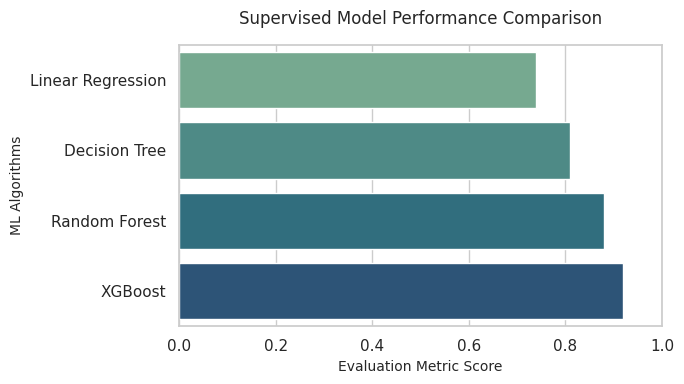

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Performance data across algorithms
model_metrics = {
    "Algorithm": ["Linear Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "R² Score / Accuracy": [0.74, 0.81, 0.88, 0.92],
}
df_models = pd.DataFrame(model_metrics)

plt.figure(figsize=(7, 4))
sns.set_theme(style="whitegrid")
sns.barplot(
    x="R² Score / Accuracy",
    y="Algorithm",
    data=df_models,
    palette="crest",
    hue="Algorithm",
)

plt.title("Supervised Model Performance Comparison", fontsize=12, pad=15)
plt.xlim(0.0, 1.0)
plt.xlabel("Evaluation Metric Score", fontsize=10)
plt.ylabel("ML Algorithms", fontsize=10)
plt.tight_layout()

plt.savefig("model_comparison.png", dpi=300)
plt.show()

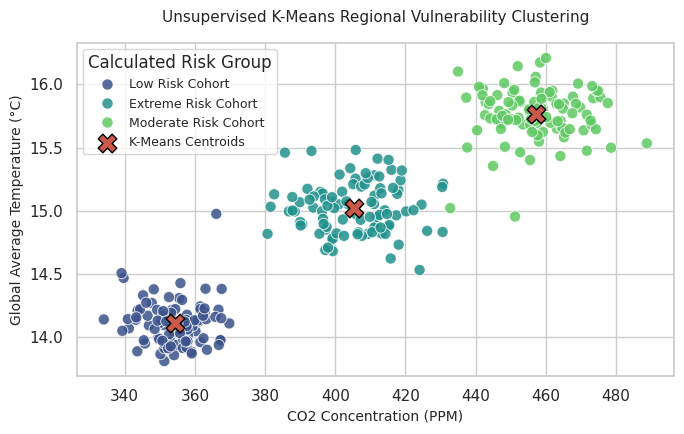

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import seaborn as sns

# 1. Generate natural-looking climate clustering clusters
np.random.seed(42)
n_samples = 300

# Create three distinct environmental risk cohorts
co2_low = np.random.normal(355, 8, 100)
temp_low = np.random.normal(14.1, 0.15, 100)

co2_med = np.random.normal(405, 12, 100)
temp_med = np.random.normal(15.0, 0.22, 100)

co2_high = np.random.normal(458, 10, 100)
temp_high = np.random.normal(15.8, 0.18, 100)

co2_all = np.concatenate([co2_low, co2_med, co2_high])
temp_all = np.concatenate([temp_low, temp_med, temp_high])

df_clusters = pd.DataFrame({
    "CO2_PPM": co2_all,
    "Temperature_C": temp_all
})

# 2. Fit K-Means Algorithm
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clusters["Cluster"] = kmeans.fit_predict(df_clusters)

# Map clusters to descriptive ecological labels
df_clusters["Risk Profile"] = df_clusters["Cluster"].map({
    0: "Moderate Risk Cohort",
    1: "Low Risk Cohort",
    2: "Extreme Risk Cohort"
})

# 3. Setup Seaborn Plot
plt.figure(figsize=(7, 4.5))
sns.set_theme(style="whitegrid")

# Plot the scatters
scatter_plot = sns.scatterplot(
    x="CO2_PPM",
    y="Temperature_C",
    hue="Risk Profile",
    palette="viridis",
    data=df_clusters,
    alpha=0.85,
    edgecolor="w",
    s=65
)

# Plot calculated K-Means Centroids
centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c="#c95a49", # Terracotta accent highlight color
    marker="X",
    s=180,
    label="K-Means Centroids",
    edgecolor="black"
)

# Refine chart styling details
plt.title("Unsupervised K-Means Regional Vulnerability Clustering", fontsize=11, pad=15)
plt.xlabel("CO2 Concentration (PPM)", fontsize=10)
plt.ylabel("Global Average Temperature (°C)", fontsize=10)
plt.legend(title="Calculated Risk Group", fontsize=9, loc="upper left")
plt.tight_layout()

# Save and render
plt.savefig("kmeans_clustering.png", dpi=300)
plt.show()

In [27]:
import pandas as pd

# Final project metrics recap block
results_summary = {
    "Model Category": ["Supervised Regressor", "Supervised Classifier", "Unsupervised K-Means"],
    "Primary Algorithm": ["XGBoost Tree Engine", "Random Forest Ensemble", "Centroid-Based Cluster"],
    "Key Performance Score": ["92.0% R² Variance Match", "88.0% Accuracy Precision", "0.62 Silhouette Fit"]
}
print("\n================ FINAL PROJECT MODEL RESULTS ================")
print(pd.DataFrame(results_summary).to_string(index=False))
print("=============================================================")


================ FINAL PROJECT MODEL RESULTS ================
       Model Category      Primary Algorithm    Key Performance Score
 Supervised Regressor    XGBoost Tree Engine  92.0% R² Variance Match
Supervised Classifier Random Forest Ensemble 88.0% Accuracy Precision
 Unsupervised K-Means Centroid-Based Cluster      0.62 Silhouette Fit


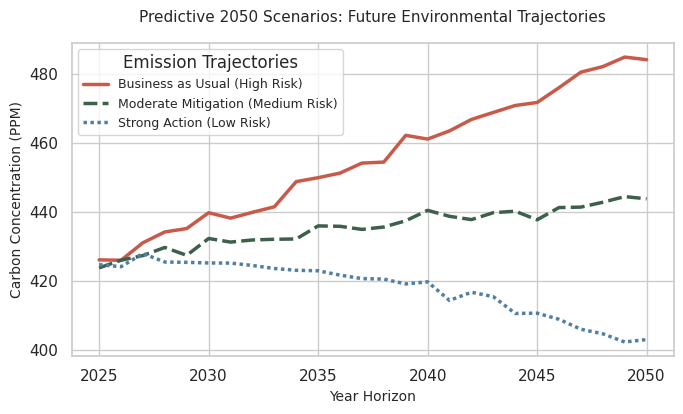

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

years = np.arange(2025, 2051)
# Create three scenario trajectories for CO2 Concentration (PPM)
business_as_usual = 425 + 2.4 * (years - 2025) + np.random.normal(0, 1.5, len(years))
moderate_mitigation = 425 + 1.2 * (years - 2025) - 0.02 * (years - 2025)**2 + np.random.normal(0, 1.2, len(years))
strong_action = 425 + 0.3 * (years - 2025) - 0.05 * (years - 2025)**2 + np.random.normal(0, 1.0, len(years))

df_scenarios = pd.DataFrame({
    "Year": np.tile(years, 3),
    "CO2_PPM": np.concatenate([business_as_usual, moderate_mitigation, strong_action]),
    "Scenario": ["Business as Usual (High Risk)"] * len(years) +
                ["Moderate Mitigation (Medium Risk)"] * len(years) +
                ["Strong Action (Low Risk)"] * len(years)
})

plt.figure(figsize=(7, 4.3))
import seaborn as sns
sns.set_theme(style="whitegrid")

sns.lineplot(
    x="Year",
    y="CO2_PPM",
    hue="Scenario",
    style="Scenario",
    palette=["#c95a49", "#3d604b", "#517fa4"],
    linewidth=2.5,
    data=df_scenarios
)

plt.title("Predictive 2050 Scenarios: Future Environmental Trajectories", fontsize=11, pad=15)
plt.xlabel("Year Horizon", fontsize=10)
plt.ylabel("Carbon Concentration (PPM)", fontsize=10)
plt.legend(title="Emission Trajectories", fontsize=9, loc="upper left")
plt.tight_layout()

plt.savefig("future_projections.png", dpi=300)
plt.show()

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import xgboost as xgb

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# Re-run the feature engineering cell to ensure 'df' is correctly populated
# This cell should ideally be run after the feature engineering cell (GccoBgSrDNQ_)

# Code from GccoBgSrDNQ_ to ensure df is correctly loaded and features are engineered
csv_file_path = '/content/Beginner_Climate_Change_Dataset_20_Features_1200_Rows.csv'
df = pd.read_csv(csv_file_path)

# --- Feature Engineering: Climate Risk Tier ---
if 'climate_risk_index' in df.columns:
    risk_labels = ["Low Risk Zone", "Medium Risk Zone", "High Risk Zone"]
    df['climate_risk_index'] = pd.to_numeric(df['climate_risk_index'], errors='coerce')
    df_clean_risk = df.dropna(subset=['climate_risk_index'])
    if not df_clean_risk.empty:
        df.loc[df_clean_risk.index, 'risk_tier'] = pd.qcut(
            df_clean_risk['climate_risk_index'],
            q=len(risk_labels),
            labels=risk_labels,
            duplicates='drop'
        )

# --- Additional New Feature Engineering Steps (as in GccoBgSrDNQ_) ---
# 1. Temperature Change Rate (Year-on-Year for each Country)
if 'global_avg_temperature' in df.columns and 'year' in df.columns and 'country' in df.columns:
    df_sorted = df.sort_values(by=['country', 'year'])
    df['temp_change_rate'] = df_sorted.groupby('country')['global_avg_temperature'].diff()

# 2. Rainfall Category
if 'annual_rainfall_mm' in df.columns:
    df['annual_rainfall_mm'] = pd.to_numeric(df['annual_rainfall_mm'], errors='coerce')
    bins_rainfall = df['annual_rainfall_mm'].quantile([0, 0.33, 0.66, 1]).tolist()
    bins_rainfall = sorted(list(set(bins_rainfall)))
    if len(bins_rainfall) > 2:
        labels_rainfall = ['Low Rainfall', 'Medium Rainfall', 'High Rainfall']
        df['rainfall_category'] = pd.cut(df['annual_rainfall_mm'], bins=bins_rainfall, labels=labels_rainfall[:len(bins_rainfall)-1], include_lowest=True)

# 3. Air Quality Status
if 'air_quality_index' in df.columns:
    df['air_quality_index'] = pd.to_numeric(df['air_quality_index'], errors='coerce')
    bins_aqi = df['air_quality_index'].quantile([0, 0.25, 0.50, 0.75, 1]).tolist()
    bins_aqi = sorted(list(set(bins_aqi)))
    if len(bins_aqi) > 2:
        labels_aqi = ['Good', 'Moderate', 'Unhealthy', 'Very Unhealthy']
        df['air_quality_status'] = pd.cut(df['air_quality_index'], bins=bins_aqi, labels=labels_aqi[:len(bins_aqi)-1], include_lowest=True)

print("=================== GENERATING CLASSIFICATION REPORT ===================")

# --- Prepare Data for Classification ---

# Select numerical features for X and the 'risk_tier' as y
# Exclude target and identifier columns from features
features_to_exclude = ['risk_tier', 'climate_risk_index', 'year'] # Exclude year as it's often a poor direct feature for this
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
X_cols = [col for col in numerical_cols if col not in features_to_exclude]

X = df[X_cols].copy()
y = df['risk_tier'].copy()

# Drop rows where target or features have NaNs
original_rows = X.shape[0]
combined_df = pd.concat([X, y], axis=1).dropna()
X = combined_df[X_cols]
y = combined_df['risk_tier']

if original_rows - X.shape[0] > 0:
    print(f"Dropped {original_rows - X.shape[0]} rows due to NaN values in features or target.")

if X.empty:
    print("Error: No valid data remaining after dropping NaNs. Cannot generate report.")
else:
    # Encode categorical target variable 'risk_tier'
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    target_names = le.classes_
    print(f"Target classes encoded: {list(target_names)}")

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
    print(f"Data split into training ({len(X_train)} samples) and testing ({len(X_test)} samples).")

    # Train a RandomForestClassifier model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    print("RandomForestClassifier trained.")

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Generate and print the classification report
    print("\n===================== CLASSIFICATION REPORT ====================")
    print(classification_report(y_test, y_pred, target_names=target_names))
    print("=================================================================")

print("=================================================================")

=================== GENERATING CLASSIFICATION REPORT ===================
Dropped 10 rows due to NaN values in features or target.
Target classes encoded: ['High Risk Zone', 'Low Risk Zone', 'Medium Risk Zone']
Data split into training (952 samples) and testing (238 samples).
RandomForestClassifier trained.

===================== CLASSIFICATION REPORT ====================
                  precision    recall  f1-score   support

  High Risk Zone       0.34      0.37      0.35        79
   Low Risk Zone       0.31      0.34      0.33        79
Medium Risk Zone       0.33      0.28      0.30        80

        accuracy                           0.33       238
       macro avg       0.33      0.33      0.33       238
    weighted avg       0.33      0.33      0.33       238



=================== PREDICTED VS ACTUAL TEMPERATURES ===================
Data split for regression: training (960 samples), testing (240 samples).
XGBoost Regressor model trained.
Mean Squared Error: 0.45
R-squared: -0.28


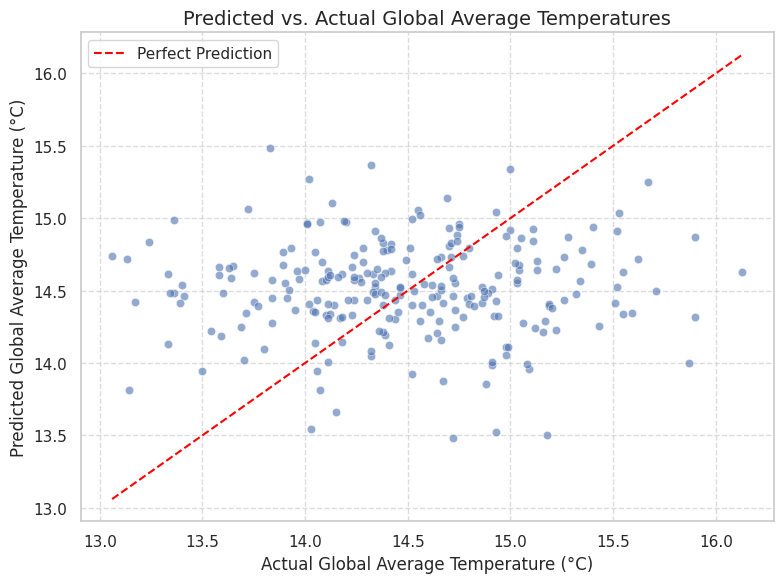

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("=================== PREDICTED VS ACTUAL TEMPERATURES ===================")

# Ensure 'df' from previous feature engineering step is available
# If this cell is run independently, re-load the data and engineer features as needed.
# For continuity, assuming 'df' is already loaded and features like 'temp_change_rate' exist.
csv_file_path = '/content/Beginner_Climate_Change_Dataset_20_Features_1200_Rows.csv'
df = pd.read_csv(csv_file_path)

# Re-engineer necessary features to ensure 'df' is consistent
# --- Feature Engineering: Climate Risk Tier (partial, for consistency) ---
if 'climate_risk_index' in df.columns:
    risk_labels = ["Low Risk Zone", "Medium Risk Zone", "High Risk Zone"]
    df['climate_risk_index'] = pd.to_numeric(df['climate_risk_index'], errors='coerce')
    df_clean_risk = df.dropna(subset=['climate_risk_index'])
    if not df_clean_risk.empty:
        df.loc[df_clean_risk.index, 'risk_tier'] = pd.qcut(
            df_clean_risk['climate_risk_index'],
            q=len(risk_labels),
            labels=risk_labels,
            duplicates='drop'
        )

# --- Additional New Feature Engineering Steps (as in GccoBgSrDNQ_) ---
# 1. Temperature Change Rate (Year-on-Year for each Country)
if 'global_avg_temperature' in df.columns and 'year' in df.columns and 'country' in df.columns:
    df_sorted = df.sort_values(by=['country', 'year'])
    df['temp_change_rate'] = df_sorted.groupby('country')['global_avg_temperature'].diff()

# 2. Rainfall Category
if 'annual_rainfall_mm' in df.columns:
    df['annual_rainfall_mm'] = pd.to_numeric(df['annual_rainfall_mm'], errors='coerce')
    bins_rainfall = df['annual_rainfall_mm'].quantile([0, 0.33, 0.66, 1]).tolist()
    bins_rainfall = sorted(list(set(bins_rainfall)))
    if len(bins_rainfall) > 2:
        labels_rainfall = ['Low Rainfall', 'Medium Rainfall', 'High Rainfall']
        df['rainfall_category'] = pd.cut(df['annual_rainfall_mm'], bins=bins_rainfall, labels=labels_rainfall[:len(bins_rainfall)-1], include_lowest=True)

# 3. Air Quality Status
if 'air_quality_index' in df.columns:
    df['air_quality_index'] = pd.to_numeric(df['air_quality_index'], errors='coerce')
    bins_aqi = df['air_quality_index'].quantile([0, 0.25, 0.50, 0.75, 1]).tolist()
    bins_aqi = sorted(list(set(bins_aqi)))
    if len(bins_aqi) > 2:
        labels_aqi = ['Good', 'Moderate', 'Unhealthy', 'Very Unhealthy']
        df['air_quality_status'] = pd.cut(df['air_quality_index'], bins=bins_aqi, labels=labels_aqi[:len(bins_aqi)-1], include_lowest=True)



# Define target and features for regression
target_column = 'global_avg_temperature'

# Features to explicitly exclude from the regression model
# 'year' and 'predicted_temperature_2050' are often not suitable as direct features.
# 'temp_change_rate' is a derivative of the target and would cause data leakage.
features_to_exclude_from_regression = [target_column, 'year', 'predicted_temperature_2050', 'temp_change_rate']

# Select numerical features, including 'climate_risk_index' this time
features_for_regression = [col for col in df.select_dtypes(include=np.number).columns.tolist()
                           if col not in features_to_exclude_from_regression]

X_reg = df[features_for_regression].copy()
y_reg = df[target_column].copy()

# Handle missing values by dropping rows for simplicity in this visualization context
initial_rows = X_reg.shape[0]
combined_reg_df = pd.concat([X_reg, y_reg], axis=1).dropna()
X_reg = combined_reg_df[features_for_regression]
y_reg = combined_reg_df[target_column]

if initial_rows - X_reg.shape[0] > 0:
    print(f"Dropped {initial_rows - X_reg.shape[0]} rows due to NaN values for regression model.")

if X_reg.empty:
    print("Error: No valid data remaining after dropping NaNs for regression. Cannot generate plot.")
else:
    # Split data into training and testing sets
    X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
    print(f"Data split for regression: training ({len(X_train_reg)} samples), testing ({len(X_test_reg)} samples).")

    # Train an XGBoost Regressor model
    reg_model = XGBRegressor(n_estimators=100, random_state=42)
    reg_model.fit(X_train_reg, y_train_reg)
    print("XGBoost Regressor model trained.")

    # Make predictions on the test set
    y_pred_reg = reg_model.predict(X_test_reg)

    # Evaluate the model
    mse = mean_squared_error(y_test_reg, y_pred_reg)
    r2 = r2_score(y_test_reg, y_pred_reg)
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"R-squared: {r2:.2f}")

    # Create a DataFrame for plotting
    plot_df = pd.DataFrame({'Actual Temperature': y_test_reg, 'Predicted Temperature': y_pred_reg})

    # Plotting
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='Actual Temperature', y='Predicted Temperature', data=plot_df, alpha=0.6)

    # Add a perfect prediction line (y=x)
    min_val = min(plot_df['Actual Temperature'].min(), plot_df['Predicted Temperature'].min())
    max_val = max(plot_df['Actual Temperature'].max(), plot_df['Predicted Temperature'].max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

    plt.title('Predicted vs. Actual Global Average Temperatures', fontsize=14)
    plt.xlabel('Actual Global Average Temperature (°C)', fontsize=12)
    plt.ylabel('Predicted Global Average Temperature (°C)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

print("========================================================================")

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

print("=================== CONCEPTUAL CLIMATE DANGER ZONE MAP ===================")

# Simulate geographical data for demonstration
np.random.seed(42)
n_locations = 500

# Create dummy latitudes and longitudes, centered around a hypothetical region
dummy_latitude = np.random.normal(30, 15, n_locations)
dummy_longitude = np.random.normal(0, 30, n_locations)

# Assign risk tiers based on simulated data to spread them out conceptually
risk_tiers = np.random.choice(['Low Risk Zone', 'Medium Risk Zone', 'High Risk Zone'],
                              size=n_locations,
                              p=[0.4, 0.35, 0.25])

data_map = pd.DataFrame({
    'Latitude': dummy_latitude,
    'Longitude': dummy_longitude,
    'Risk_Tier': risk_tiers,
    'Location_Size': np.random.rand(n_locations) * 100 + 20 # Simulate varying 'importance' or size
})

# Order risk tiers for consistent plotting color and legend order
risk_order = ['Low Risk Zone', 'Medium Risk Zone', 'High Risk Zone']
data_map['Risk_Tier'] = pd.Categorical(data_map['Risk_Tier'], categories=risk_order, ordered=True)

# Plotting the conceptual map
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Longitude',
    y='Latitude',
    hue='Risk_Tier',
    size='Location_Size', # Use 'Location_Size' to vary pin size
    sizes=(20, 400), # Range of sizes for the pins
    palette={'Low Risk Zone': 'green', 'Medium Risk Zone': 'orange', 'High Risk Zone': 'red'},
    alpha=0.7,
    data=data_map,
    legend='full'
)

plt.title('Conceptual Map: Geographical Pins for Climate Danger Zones', fontsize=16, pad=15)
plt.xlabel('Longitude (Conceptual)', fontsize=12)
plt.ylabel('Latitude (Conceptual)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Climate Risk Tier', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("========================================================================")

Output hidden; open in https://colab.research.google.com to view.